In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import set_config
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
import scipy as sp
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from scipy.stats import norm
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

import geopandas as gpd
from dotenv import load_dotenv
from tqdm import tqdm

In [3]:
from google.colab import files
uploaded = files.upload()

Saving carbonmonitor-global_datas_2025-10-07.csv to carbonmonitor-global_datas_2025-10-07.csv


In [4]:
import pandas as pd
df = pd.read_csv('carbonmonitor-global_datas_2025-10-07.csv')
df.head()

,country,date,sector,value,Unnamed: 4
0,Brazil,01/01/2019,Industry,0.216618,NaN
1,Brazil,01/01/2019,Ground Transport,0.215540,NaN
2,Brazil,01/01/2019,International Aviation,0.020050,NaN
3,Brazil,01/01/2019,Domestic Aviation,0.019680,NaN
4,Brazil,01/01/2019,Residential,0.110618,NaN


In [5]:
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])
df.head()

,country,date,sector,value
0,Brazil,01/01/2019,Industry,0.216618
1,Brazil,01/01/2019,Ground Transport,0.215540
2,Brazil,01/01/2019,International Aviation,0.020050
3,Brazil,01/01/2019,Domestic Aviation,0.019680
4,Brazil,01/01/2019,Residential,0.110618


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204540 entries, 0 to 204539
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   country  204540 non-null  object 
 1   date     204540 non-null  object 
 2   sector   204540 non-null  object 
 3   value    204540 non-null  float64
dtypes: float64(1), object(3)
memory usage: 6.2+ MB


In [7]:
print("Number of countries: " + str(df['country'].nunique()))
df['country'].unique()

Number of countries: 14


array(['Brazil', 'China', 'EU27 & UK', 'France', 'Germany', 'India',
       'Italy', 'Japan', 'ROW', 'Russia', 'Spain', 'United Kingdom',
       'United States', 'WORLD'], dtype=object)

In [8]:
df['sector'].unique()

array(['Industry', 'Ground Transport', 'International Aviation',
       'Domestic Aviation', 'Residential', 'Power'], dtype=object)

In [9]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['date'].min(), df['date'].max()

(Timestamp('2019-01-01 00:00:00'), Timestamp('2025-08-31 00:00:00'))

In [10]:
%pip install wbgapi

In [11]:
import wbgapi as wb

def fetch_pop_gdp(countries_iso3, years_range):
    """
    countries_iso3: lista ISO3 (es. ['ITA','USA','CHN'])
    years_range: es. range(2021, 2024) -> 2021, 2022, 2023
    Ritorna un DF long con: country, year, population, gdp
    """
    POP = "SP.POP.TOTL"
    GDP = "NY.GDP.MKTP.CD"

    # Ottieni DF "wide": indici = economy, colonne = anni
    pop_wide = wb.data.DataFrame(POP, economy=countries_iso3,
                                 time=years_range, labels=False, numericTimeKeys=True)
    gdp_wide = wb.data.DataFrame(GDP, economy=countries_iso3,
                                 time=years_range, labels=False, numericTimeKeys=True)

    # Converte in "long"
    # Indice (economy) + colonna anno (stack) → valore
    pop_long = (
        pop_wide.stack()
        .rename('population')
        .reset_index()
        .rename(columns={'economy': 'country', 'level_1': 'year'})
    )
    gdp_long = (
        gdp_wide.stack()
        .rename('gdp')
        .reset_index()
        .rename(columns={'economy': 'country', 'level_1': 'year'})
    )

    # Tipi
    pop_long['year'] = pop_long['year'].astype(int)
    gdp_long['year'] = gdp_long['year'].astype(int)

    # Merge finale
    out = pd.merge(pop_long, gdp_long, on=['country', 'year'], how='outer')
    return out

# Esempio
countries =  ["BRA","CHN","FRA","DEU","IND","ITA","JPN","RUS","ESP","GBR","USA"]
years = range(2019, 2025)
pop_gdp_df = fetch_pop_gdp(countries, years)
print(pop_gdp_df.head())


  country  year   population           gdp
0     BRA  2019  207455459.0  1.873288e+12
1     BRA  2020  208660842.0  1.476107e+12
2     BRA  2021  209550294.0  1.670647e+12
3     BRA  2022  210306415.0  1.951924e+12
4     BRA  2023  211140729.0  2.191132e+12


In [12]:
# ==========================================================
# 🔹 CREAZIONE DATAFRAME NORMALIZZATO (giornaliero e annuale)
# ==========================================================

# Mapping nome → ISO3 per i paesi del dataset
name_to_iso3 = {
    "Brazil": "BRA",
    "China": "CHN",
    "France": "FRA",
    "Germany": "DEU",
    "India": "IND",
    "Italy": "ITA",
    "Japan": "JPN",
    "Russia": "RUS",
    "Spain": "ESP",
    "United Kingdom": "GBR",
    "United States": "USA",
}

# Copia del dataframe principale delle emissioni
df_norm = df.copy()

# Conversione date e aggiunta colonna year
df_norm["date"] = pd.to_datetime(df_norm["date"], dayfirst=True, errors="coerce")
df_norm["year"] = df_norm["date"].dt.year

# Escludi aggregati non compatibili con World Bank
exclude = {"WORLD", "ROW", "EU27 & UK"}
df_norm = df_norm[~df_norm["country"].isin(exclude)].copy()

# Aggiungi colonna ISO3
df_norm["country_iso3"] = df_norm["country"].map(name_to_iso3).fillna(df_norm["country"])

# Merge con i dati di popolazione e GDP
df_norm = df_norm.merge(
    pop_gdp_df,
    left_on=["country_iso3", "year"],
    right_on=["country", "year"],
    how="left",
    suffixes=("", "_wb")
)

# Rinomina e pulizia colonne
df_norm = df_norm.rename(columns={'country': 'country_name'})
if 'country_wb' in df_norm.columns:
    df_norm = df_norm.drop(columns=['country_wb'])

# ==========================================================
# 🔹 CALCOLO NORMALIZZAZIONI GIORNALIERE
# ==========================================================

# Conversione MtCO2 → tonnellate
df_norm["tCO2_day"] = df_norm["value"] * 1e6

# Emissioni pro capite (tonnellate per persona al giorno)
df_norm["tCO2_per_capita_day"] = df_norm["tCO2_day"] / df_norm["population"]

# Emissioni per GDP (tonnellate per milione di USD al giorno)
df_norm["tCO2_per_million_USD_day"] = df_norm["tCO2_day"] / (df_norm["gdp"] / 1e6)

# ==========================================================
# 🔹 CALCOLO NORMALIZZAZIONI ANNUALI (aggregazione per paese)
# ==========================================================

annual_df = (
    df_norm.groupby(["country_iso3", "country_name", "year"], as_index=False)
           .agg(MtCO2_per_year=("value", "sum"),
                population=("population", "first"),
                gdp=("gdp", "first"))
)

# Conversione MtCO2 → tonnellate e normalizzazione annuale
annual_df["tCO2_per_capita_year"] = (annual_df["MtCO2_per_year"] * 1e6) / annual_df["population"]
annual_df["tCO2_per_million_USD_year"] = (annual_df["MtCO2_per_year"] * 1e6) / (annual_df["gdp"] / 1e6)

# Ordinamento
df_norm = df_norm.sort_values(["country_iso3", "date"]).reset_index(drop=True)
annual_df = annual_df.sort_values(["country_iso3", "year"]).reset_index(drop=True)

# ==========================================================
# 🔹 OUTPUT DI CONTROLLO
# ==========================================================
print("Daily normalized emissions:")
print(df_norm[["country_name", "date", "value", "tCO2_per_capita_day", "tCO2_per_million_USD_day"]].head())

print("\n Annual normalized emissions:")
print(annual_df[["country_name", "year", "tCO2_per_capita_year", "tCO2_per_million_USD_year"]].head())


Daily normalized emissions:
  country_name       date     value  tCO2_per_capita_day  \
0       Brazil 2019-01-01  0.216618             0.001044   
1       Brazil 2019-01-01  0.215540             0.001039   
2       Brazil 2019-01-01  0.020050             0.000097   
3       Brazil 2019-01-01  0.019680             0.000095   
4       Brazil 2019-01-01  0.110618             0.000533   

   tCO2_per_million_USD_day  
0                  0.115635  
1                  0.115060  
2                  0.010703  
3                  0.010505  
4                  0.059050  

 Annual normalized emissions:
  country_name  year  tCO2_per_capita_year  tCO2_per_million_USD_year
0       Brazil  2019              1.911905                 211.732037
1       Brazil  2020              1.800919                 254.575877
2       Brazil  2021              2.015857                 252.850198
3       Brazil  2022              1.923285                 207.220809
4       Brazil  2023              1.899444        

In [13]:
print("Missing Values:")
print(df.isnull().sum())
print('\nDuplicates based on Date, Country & Sector')
df.duplicated(subset=['date', 'country', 'sector']).sum()

Missing Values:
country    0
date       0
sector     0
value      0
dtype: int64

Duplicates based on Date, Country & Sector


np.int64(0)

In [14]:
full_range = pd.date_range(start=df['date'].min(), end=df['date'].max())
missing_dates = full_range.difference(df['date'].unique())
print(f"Missing days in the dataset: {len(missing_dates)}")


Missing days in the dataset: 0


In [15]:
from tqdm import tqdm

missing_by_group = {}

for (country, sector), group in tqdm(df.groupby(['country', 'sector'])):
    group_dates = pd.to_datetime(group['date'])
    full_range = pd.date_range(start=group_dates.min(), end=group_dates.max())
    missing = full_range.difference(group_dates)
    if len(missing) > 0:
        missing_by_group[(country, sector)] = len(missing)

print(f"Number of (country, sector) pairs with missing dates: {len(missing_by_group)}")


100%|██████████| 84/84 [00:00<00:00, 174.48it/s]

Number of (country, sector) pairs with missing dates: 0


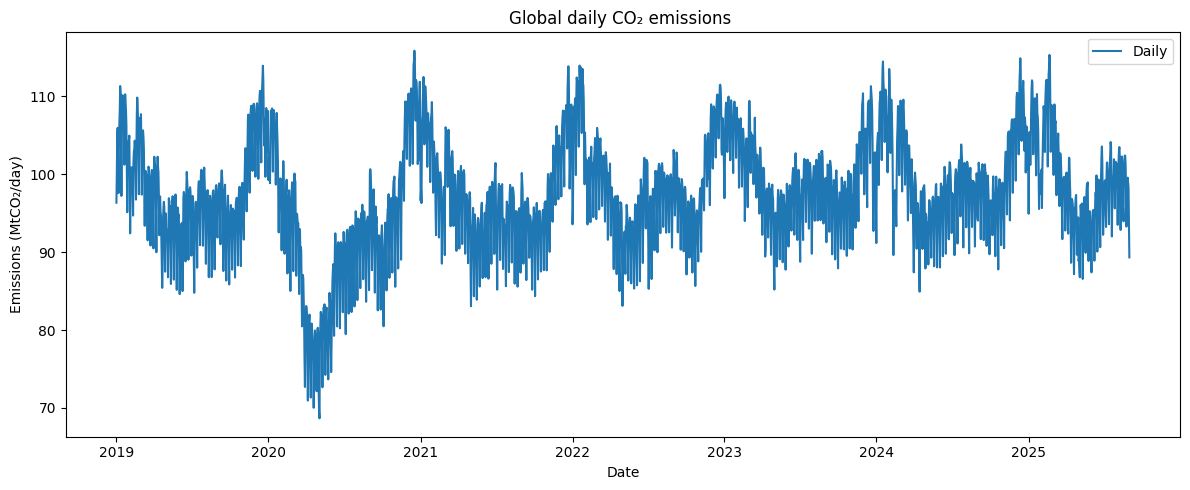

In [16]:
import matplotlib.pyplot as plt
df_world = df[df['country'] == 'WORLD']
world_daily = df_world.groupby('date', as_index=False)['value'].sum()
plt.figure(figsize=(12,5))
plt.plot(world_daily['date'], world_daily['value'], label='Daily')
plt.title('Global daily CO₂ emissions ')
plt.xlabel('Date'); plt.ylabel('Emissions (MtCO₂/day)')
plt.legend(); plt.tight_layout(); plt.show()

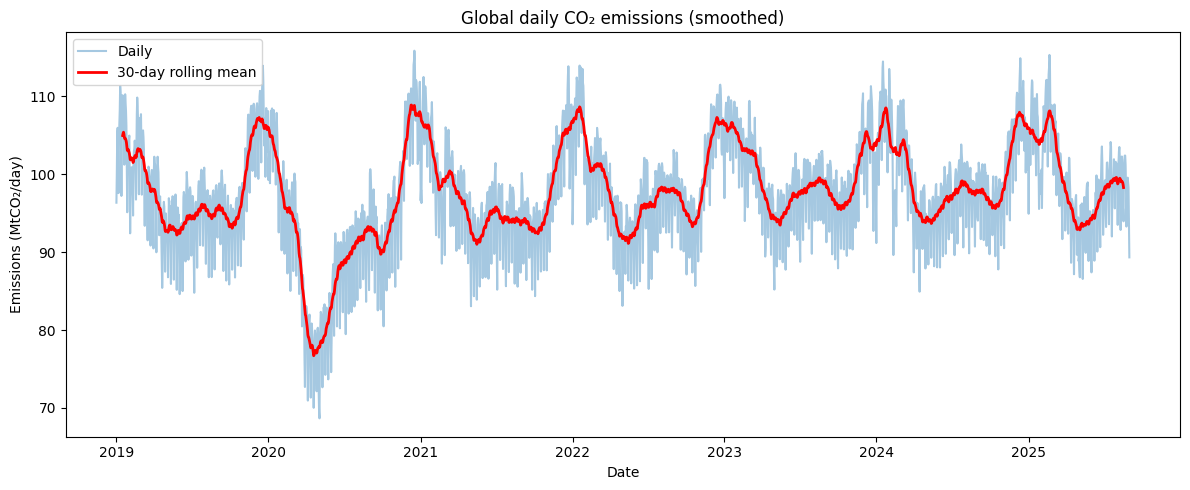

In [17]:
world_daily['rolling_30d'] = world_daily['value'].rolling(window=30, center=True).mean()

plt.figure(figsize=(12,5))
plt.plot(world_daily['date'], world_daily['value'], alpha=0.4, label='Daily')
plt.plot(world_daily['date'], world_daily['rolling_30d'], color='red', linewidth=2, label='30-day rolling mean')
plt.title('Global daily CO₂ emissions (smoothed)')
plt.xlabel('Date')
plt.ylabel('Emissions (MtCO₂/day)')
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipython-input-827055643.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  world_monthly = world_monthly.resample('M', on='date')['value'].mean().reset_index()


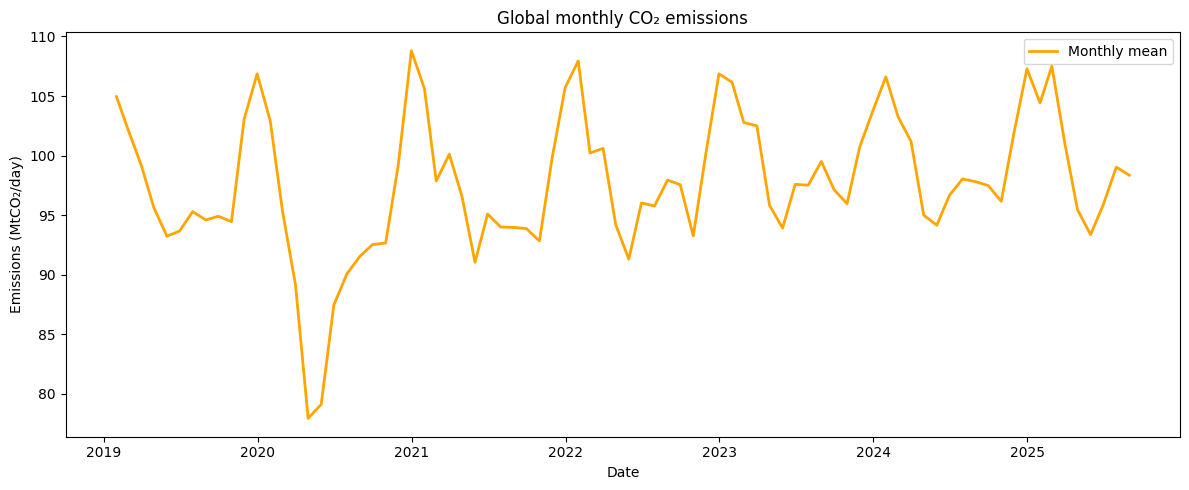

In [18]:
world_monthly = world_daily.copy()
world_monthly['date'] = pd.to_datetime(world_monthly['date'])
world_monthly = world_monthly.resample('M', on='date')['value'].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(world_monthly['date'], world_monthly['value'], color='orange', linewidth=2, label='Monthly mean')
plt.title('Global monthly CO₂ emissions')
plt.xlabel('Date')
plt.ylabel('Emissions (MtCO₂/day)')
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
world_monthly['value'].describe()


,value
count,80.000000
mean,97.715447
std,5.793266
min,77.954224
25%,94.195971
50%,97.501863
75%,101.345642
max,108.801659


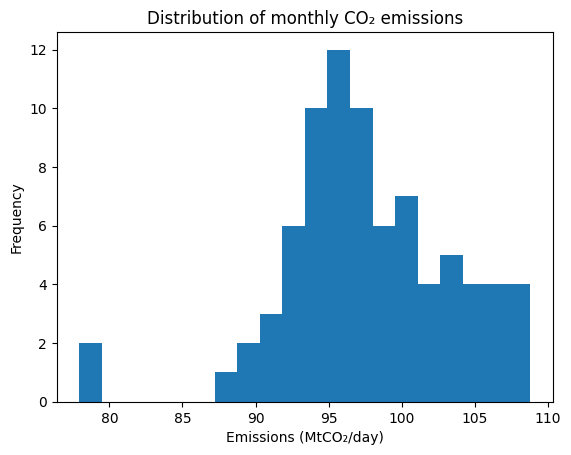

In [20]:
world_monthly['value'].plot(kind='hist', bins=20)
plt.title('Distribution of monthly CO₂ emissions')
plt.xlabel('Emissions (MtCO₂/day)')
plt.show()


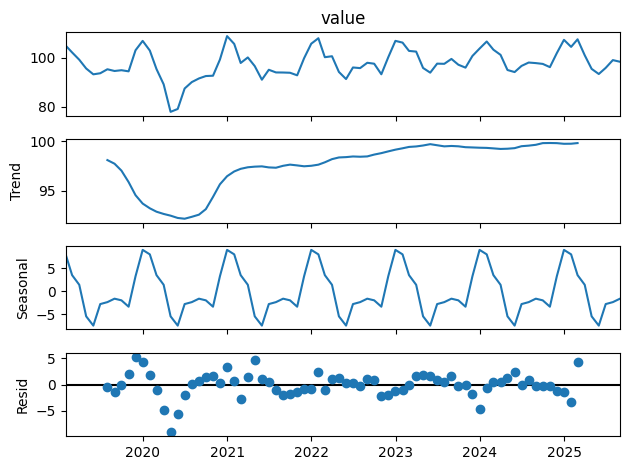

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(world_monthly.set_index('date')['value'], model='additive', period=12)
decomp.plot()
plt.show()


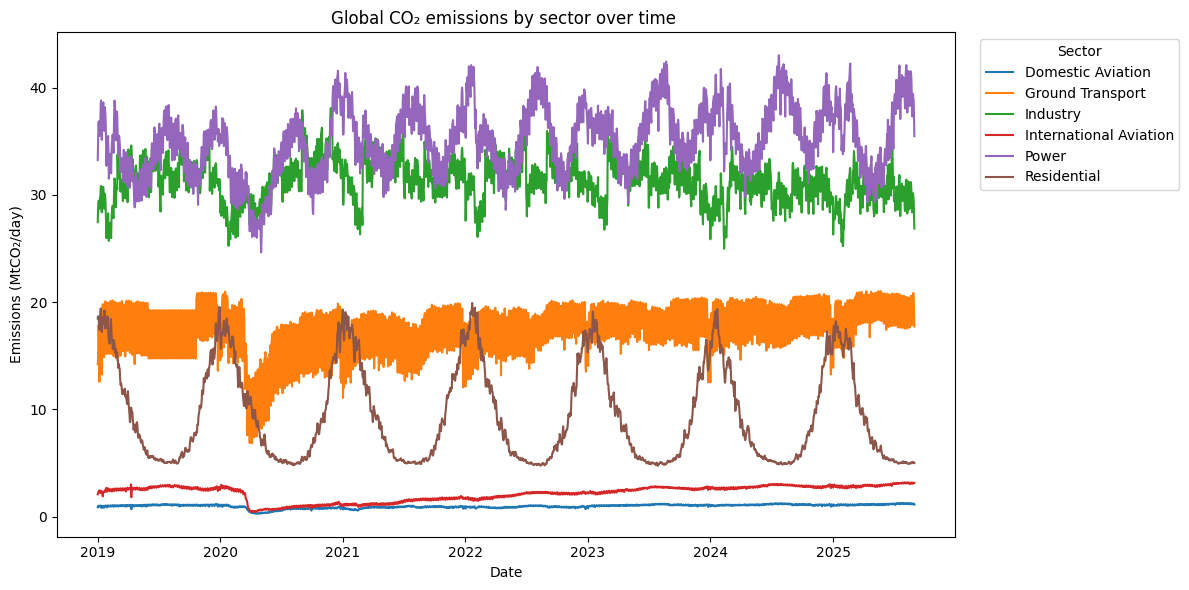

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
df_world = df[df['country'] == 'WORLD']
world_time_sector = (df_world
                     .groupby(['date', 'sector'], as_index=False)['value']
                     .sum())
plt.figure(figsize=(12,6))
sns.lineplot(data=world_time_sector, x='date', y='value', hue='sector', linewidth=1.5)
plt.title('Global CO₂ emissions by sector over time ')
plt.xlabel('Date'); plt.ylabel('Emissions (MtCO₂/day)')
plt.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

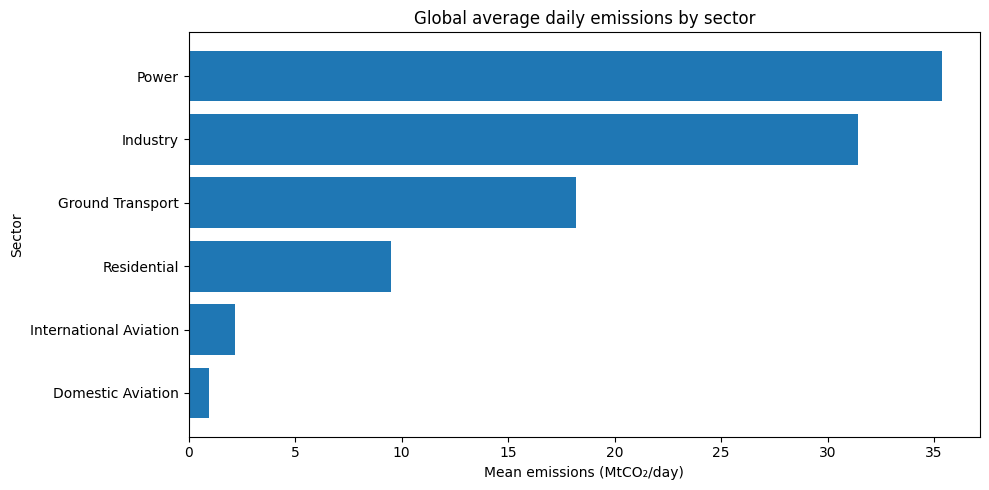

In [23]:
world_sector_mean = (df_world
                     .groupby('sector', as_index=False)['value']
                     .mean()
                     .sort_values('value', ascending=False))
plt.figure(figsize=(10,5))
plt.barh(world_sector_mean['sector'], world_sector_mean['value'])
plt.gca().invert_yaxis()
plt.title('Global average daily emissions by sector')
plt.xlabel('Mean emissions (MtCO₂/day)'); plt.ylabel('Sector')
plt.tight_layout(); plt.show()


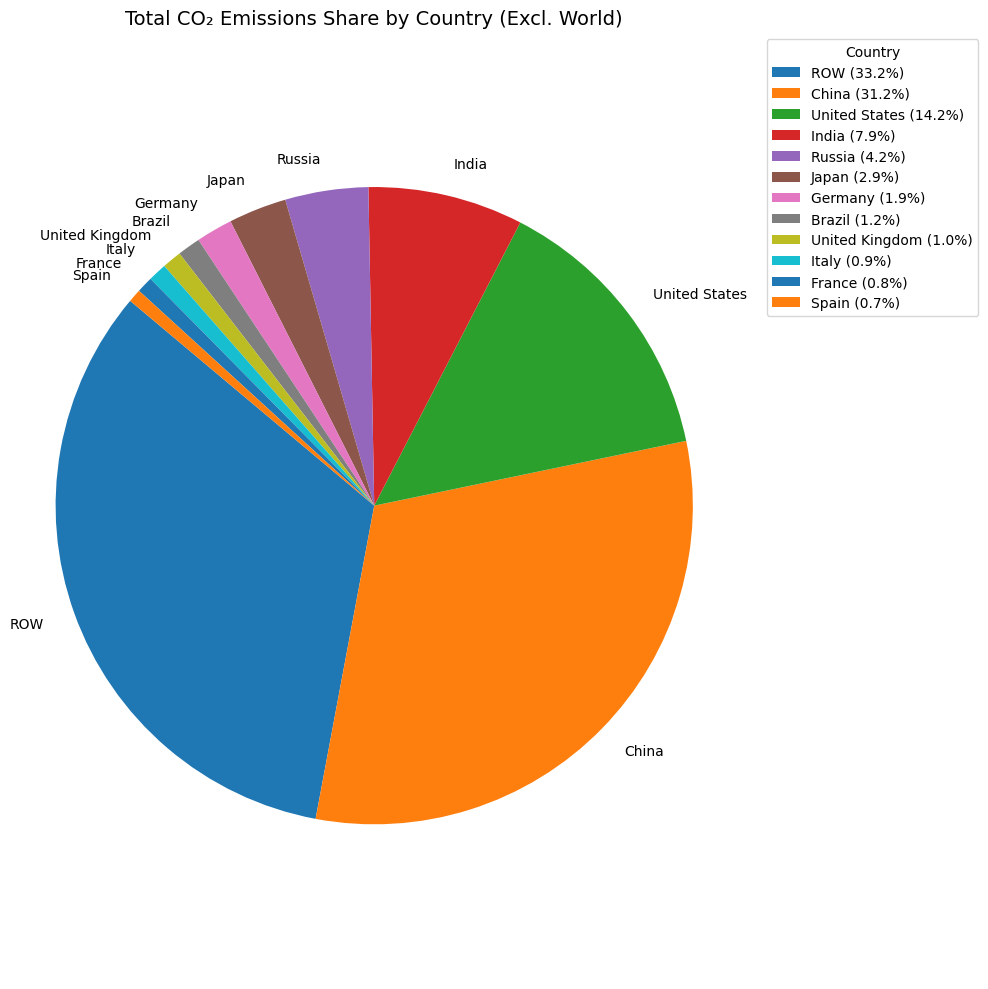

In [24]:
def plot_country_emission_pie_with_labels_and_legend(df_filtered):
    """
    Plot a pie chart of total CO₂ emissions by country (excluding 'World'),
    showing country names on the chart and full percentage breakdown in the legend.
    """

    # Total emissions per country
    total_emissions = df_filtered.groupby('country')['value'].sum().sort_values(ascending=False)
    total = total_emissions.sum()

    # Legend labels with percentage
    legend_labels = [f"{country} ({value / total * 100:.1f}%)" for country, value in total_emissions.items()]

    # Plot
    plt.figure(figsize=(10, 10))  # Reduced size
    wedges, texts = plt.pie(total_emissions, labels=total_emissions.index, startangle=140)

    # Add external legend
    plt.legend(wedges, legend_labels, title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title('Total CO₂ Emissions Share by Country (Excl. World)', fontsize=14)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


df_excld_world_and_eu = df[(df['country'].str.upper() != 'WORLD') & (df['country'].str.upper() != 'EU27 & UK')]
df_incld_eu_combined = df[(df['country'].str.upper() != 'WORLD') & (~df['country'].isin(['Germany','Brazil','United Kingdom','Italy','France','Spain']))]
plot_country_emission_pie_with_labels_and_legend(df_excld_world_and_eu)
#plot_country_emission_pie_with_labels_and_legend(df_incld_eu_combined)

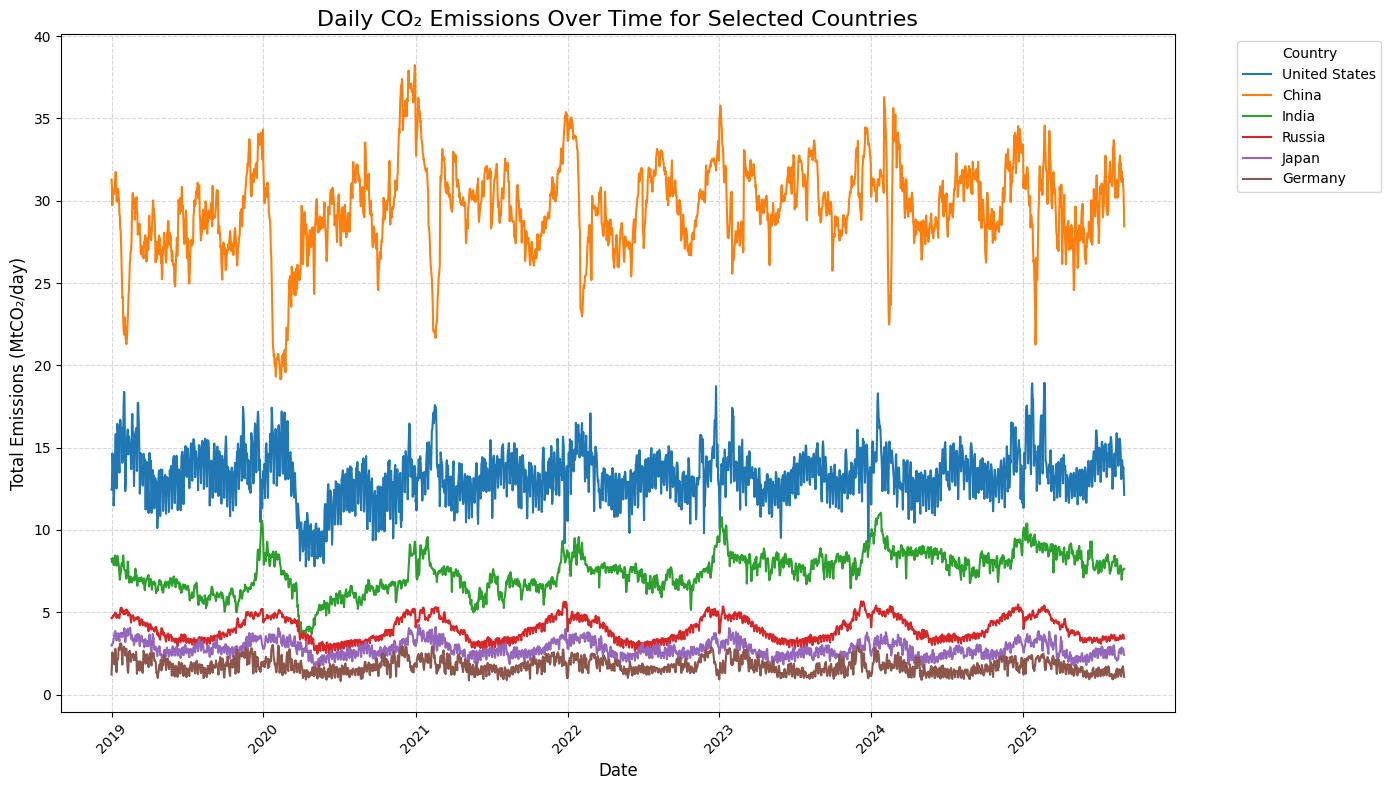

In [25]:
import matplotlib.dates as mdates

def plot_country_emissions_time_series(df, countries):
    """
    Plots the daily CO₂ emissions over time for a list of specified countries.
    """
    plt.figure(figsize=(14, 8))
    for country in countries:
        df_country = df[df['country'] == country].groupby('date')['value'].sum().reset_index()
        plt.plot(df_country['date'], df_country['value'], label=country, linewidth=1.5)

    plt.title('Daily CO₂ Emissions Over Time for Selected Countries', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Total Emissions (MtCO₂/day)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Format x-axis
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Select a few countries to plot
selected_countries = ['United States', 'China', 'India', 'Russia', 'Japan', 'Germany']
plot_country_emissions_time_series(df, selected_countries)

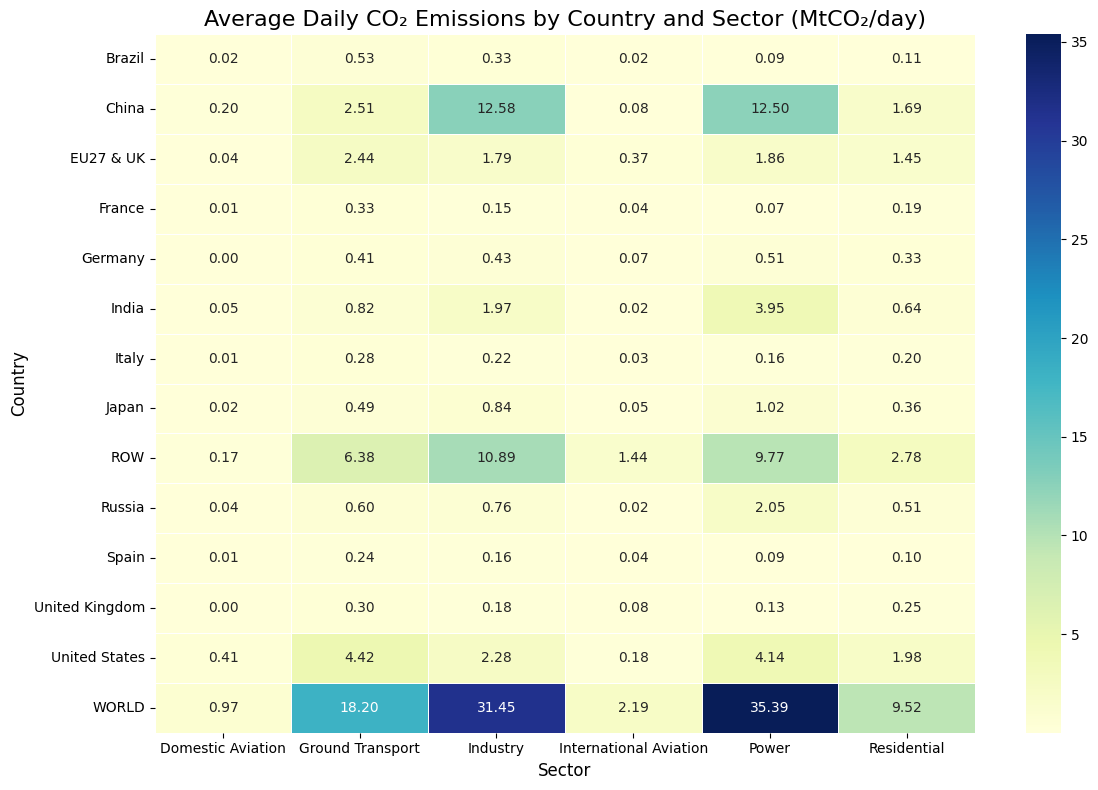

In [26]:
# Group by country, sector, and date and calculate the mean daily emission
df_grouped_heatmap = df.groupby(['country', 'sector', 'date'])['value'].mean().reset_index()

# Pivot the table to have countries as rows, sectors as columns, and mean value as values
# We'll take the mean across all dates for simplicity in this aggregated heatmap
df_pivot_heatmap = df_grouped_heatmap.pivot_table(index='country', columns='sector', values='value', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(df_pivot_heatmap, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Average Daily CO₂ Emissions by Country and Sector (MtCO₂/day)', fontsize=16)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

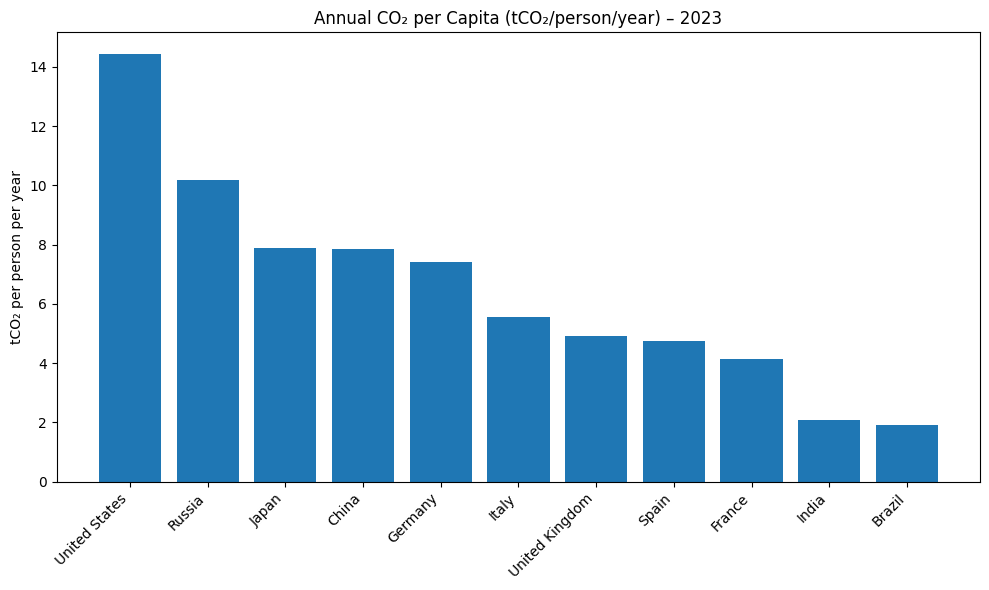

In [27]:
year_to_plot = 2023
df_plot = (annual_df[annual_df["year"] == year_to_plot]
           .dropna(subset=["tCO2_per_capita_year"])
           .sort_values("tCO2_per_capita_year", ascending=False))

plt.figure(figsize=(10, 6))
plt.bar(df_plot["country_name"], df_plot["tCO2_per_capita_year"])
plt.title(f"Annual CO₂ per Capita (tCO₂/person/year) – {year_to_plot}")
plt.ylabel("tCO₂ per person per year")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

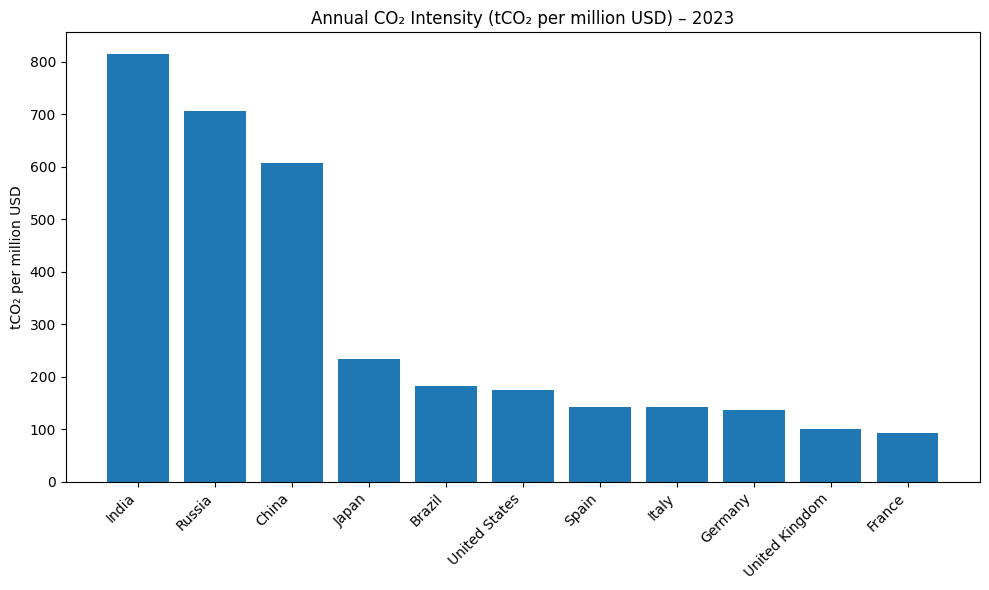

In [28]:
year_to_plot = 2023
df_plot = (annual_df[annual_df["year"] == year_to_plot]
           .dropna(subset=["tCO2_per_million_USD_year"])
           .sort_values("tCO2_per_million_USD_year", ascending=False))

plt.figure(figsize=(10, 6))
plt.bar(df_plot["country_name"], df_plot["tCO2_per_million_USD_year"])
plt.title(f"Annual CO₂ Intensity (tCO₂ per million USD) – {year_to_plot}")
plt.ylabel("tCO₂ per million USD")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [29]:
# Parameters
window_size = 30
n_bins = 5
from scipy.stats import norm
import numpy as np
from sklearn.preprocessing import StandardScaler
breakpoints = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])
symbol_map = {0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e'}

# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Aggregate CO2 values by country and date
df_country_grouped = df.groupby(['country', 'date'], as_index=False)['value'].sum()

# Dictionary to store SAX sequences
sax_by_country = {}

# Generate SAX sequence for each country
for country in df_country_grouped['country'].unique():
    df_country = df_country_grouped[df_country_grouped['country'] == country].copy()
    df_country = df_country.set_index('date').sort_index()

    # Normalize time series
    scaler = StandardScaler()
    df_country['value_norm'] = scaler.fit_transform(df_country[['value']])

    # Piecewise Aggregate Approximation (PAA)
    paa_values = df_country['value_norm'].rolling(window=window_size).mean().dropna()

    # SAX discretization
    symbols = np.digitize(paa_values, breakpoints)
    sax_sequence = ''.join([symbol_map[i] for i in symbols])

    # Store result
    sax_by_country[country] = sax_sequence

# Show first 3 SAX sequences
list(sax_by_country.items())[:3]

[('Brazil',
  'abbbbbbbbbbbbbcccccccccccccccccccccccccccccccccbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbccccccccccccccccccccccccccccccccccccccccccddddddddddddccdddddddddddddddddddcddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddddcddccccccccccccccccccccbbbbbbbbbbbbbbbccccccccccccccccccccddddddddddddddddddddddddddddddddccccccccccccccccccccbbbbbbbbbbaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaabbbbbbbbbbbbbbbbbbbbccccccccccbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbccccbcccccbccccccccccddddcddddddddddddddddddddddddddddddddddddddddddddddddddddddcccccccbbbbbbbbbbbbbbbbbbbbbbbbbbbbbcccccccccccccccccccccccccccccccccccccccccbbccccbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbbcccbbccccccccccccccccccccccccccccddddddddddddddddddddddddddddddddddddddddddddddddddddeeeddeeeeeddeeeeeddeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeee

/tmp/ipython-input-1459859694.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sax_df_num = sax_df.applymap(lambda x: symbol_order.get(x, np.nan))


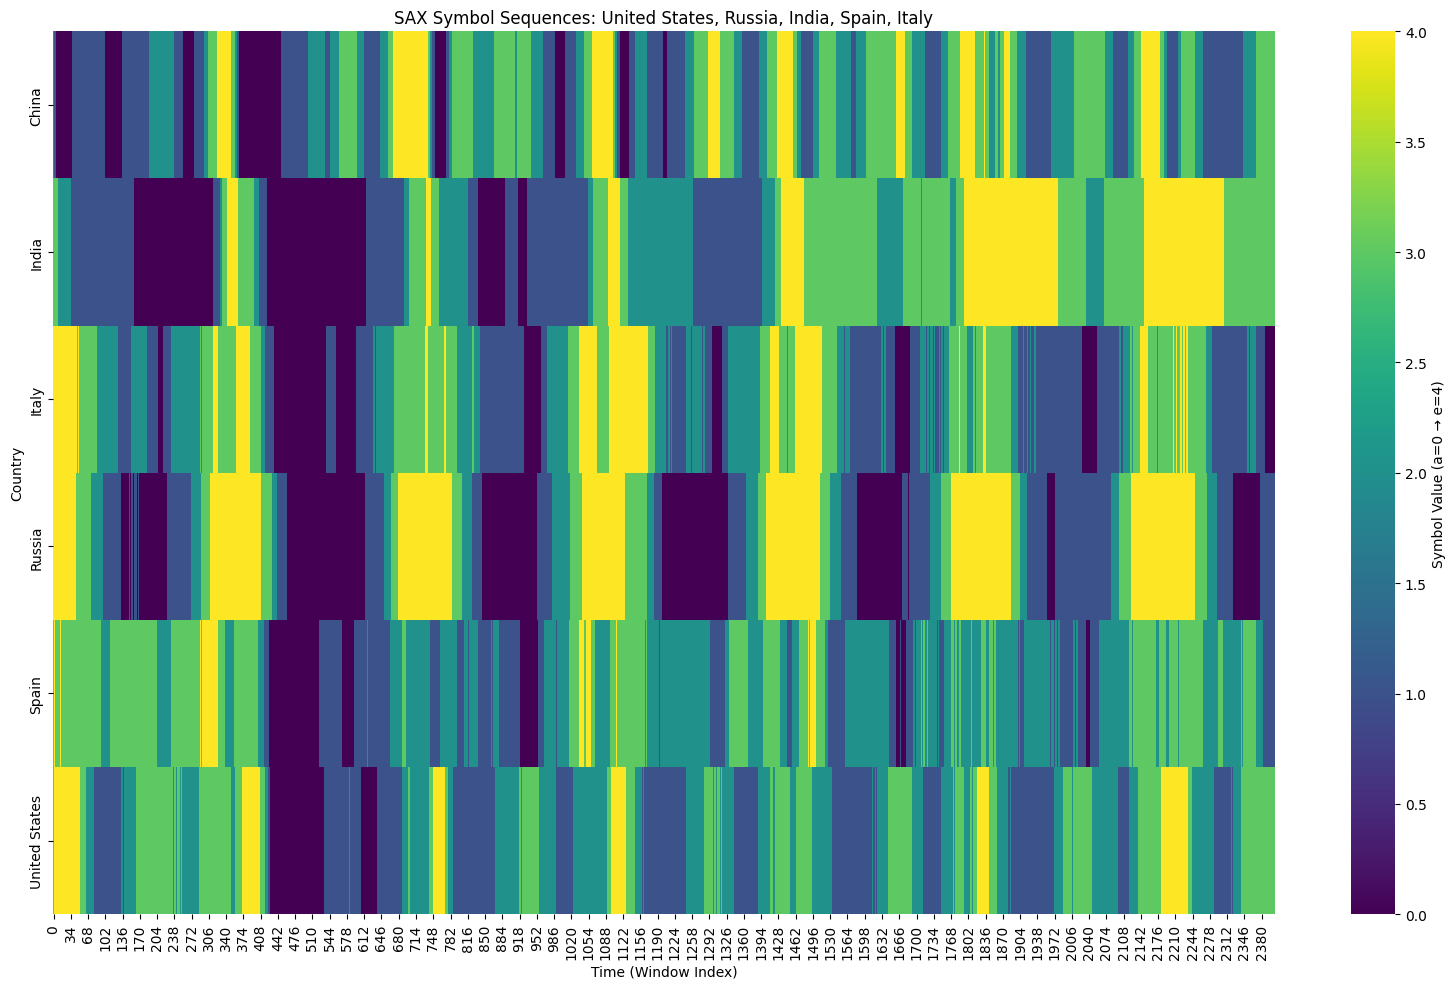

In [30]:
# Select countries to visualize
selected_countries = ['United States', 'China', 'Russia', 'India', 'Spain', 'Italy']

# Filter only the selected countries
filtered_sax = {country: seq for country, seq in sax_by_country.items() if country in selected_countries}

# Ensure equal sequence length (truncate to the minimum)
min_len = min(len(seq) for seq in filtered_sax.values())
trimmed_sax = {country: list(seq[:min_len]) for country, seq in filtered_sax.items()}

# Convert to DataFrame (countries as rows)
sax_df = pd.DataFrame(trimmed_sax).T

# Map symbols ('a'–'e') to numeric values (0–4) for visualization
symbol_order = {'a': 0, 'b': 1, 'c': 2, 'd': 3, 'e': 4}
sax_df_num = sax_df.applymap(lambda x: symbol_order.get(x, np.nan))

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    sax_df_num,
    cmap='viridis',
    cbar_kws={'label': 'Symbol Value (a=0 → e=4)'}
)
plt.title("SAX Symbol Sequences: United States, Russia, India, Spain, Italy")
plt.xlabel("Time (Window Index)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [31]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ngrams(seq, n=3):
    return [seq[i:i+n] for i in range(len(seq)-n+1)]

def fit_ngram_model(seqs_dict, n=3, alpha=1.0):
    counts = Counter()
    for s in seqs_dict.values():
        counts.update(ngrams(s, n))
    N = sum(counts.values())
    V = max(len(counts), 1)
    probs = {g: (c + alpha) / (N + alpha * V) for g, c in counts.items()}
    default_p = alpha / (N + alpha * V)
    return probs, default_p

def dates_for_country(df_country_grouped, country):
    return (df_country_grouped[df_country_grouped['country'] == country]
            .sort_values('date')['date'].reset_index(drop=True))


In [32]:
def detect_anomalies_for_country(country, sax_by_country, df_country_grouped,
                                 probs, default_p, window_size=30, n=3, top_k=5):
    # sequenza SAX del paese
    if country not in sax_by_country or len(sax_by_country[country]) < n:
        return pd.DataFrame(columns=['country','pattern','score','start_date','end_date'])
    seq = sax_by_country[country]

    # scores = -log p(ngram)
    gs = ngrams(seq, n)
    p = np.array([probs.get(g, default_p) for g in gs])
    scores = -np.log(p)

    # top-k indici
    idx = np.argsort(scores)[-top_k:][::-1]
    # mappatura simboli → date (ogni simbolo termina alla data seguente)
    dates = dates_for_country(df_country_grouped, country)
    symbol_dates = dates[window_size-1 : window_size-1 + len(seq)]

    rows = []
    for i in idx:
        start_date = symbol_dates.iloc[i]
        end_date = symbol_dates.iloc[min(i + n - 1, len(symbol_dates)-1)]
        rows.append({
            'country': country,
            'pattern': gs[i],
            'score': float(scores[i]),
            'start_date': start_date,
            'end_date': end_date
        })
    return pd.DataFrame(rows).sort_values('score', ascending=False).reset_index(drop=True)


In [33]:
def plot_country_with_anomalies(country, df_country_grouped, df_anoms):
    dfc = (df_country_grouped[df_country_grouped['country'] == country]
           .sort_values('date'))
    plt.figure(figsize=(12,5))
    plt.plot(dfc['date'], dfc['value'], label=f'{country} CO₂ series', color='black')

    for _, r in df_anoms.iterrows():
        plt.axvspan(r['start_date'], r['end_date'], color='red', alpha=0.3)

    plt.title(f"SAX-based Anomaly Detection: {country}")
    plt.xlabel("Date"); plt.ylabel("CO₂ emissions (MtCO₂/day)")
    plt.legend(); plt.tight_layout(); plt.show()


,country,pattern,score,start_date,end_date
0,WORLD,cdc,7.480369,2025-08-21,2025-08-23
1,WORLD,bcb,7.092603,2024-06-20,2024-06-22
2,WORLD,cbc,6.928300,2024-11-02,2024-11-04
3,WORLD,aab,5.829688,2022-05-22,2022-05-24
4,WORLD,aab,5.829688,2022-05-30,2022-06-01


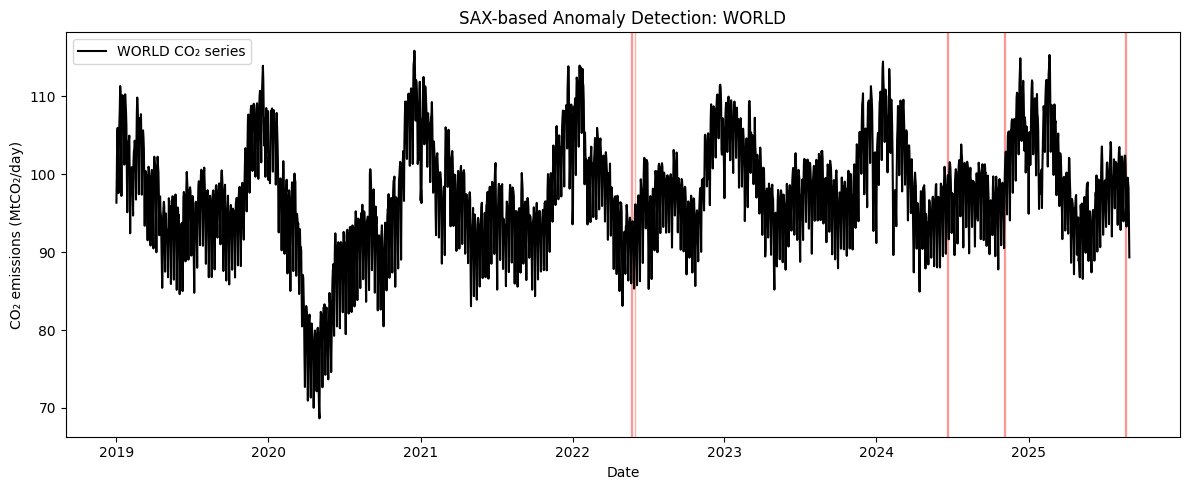

In [34]:
# 3.1 Modello di probabilità n-grammi (su tutte le sequenze per robustezza)
n = 3
probs, default_p = fit_ngram_model(sax_by_country, n=n, alpha=1.0)

#WORLD
df_anoms_world = detect_anomalies_for_country(
    "WORLD", sax_by_country, df_country_grouped,
    probs, default_p, window_size=window_size, n=n, top_k=5
)
display(df_anoms_world)
plot_country_with_anomalies("WORLD", df_country_grouped, df_anoms_world)



,country,pattern,score,start_date,end_date
0,Italy,ede,8.345366,2025-03-02,2025-03-04
1,Italy,aba,7.939901,2024-09-13,2024-09-15
2,Italy,cdc,7.480369,2021-11-05,2021-11-07
3,Italy,bab,7.289314,2024-09-14,2024-09-16
4,Italy,bab,7.289314,2020-07-25,2020-07-27


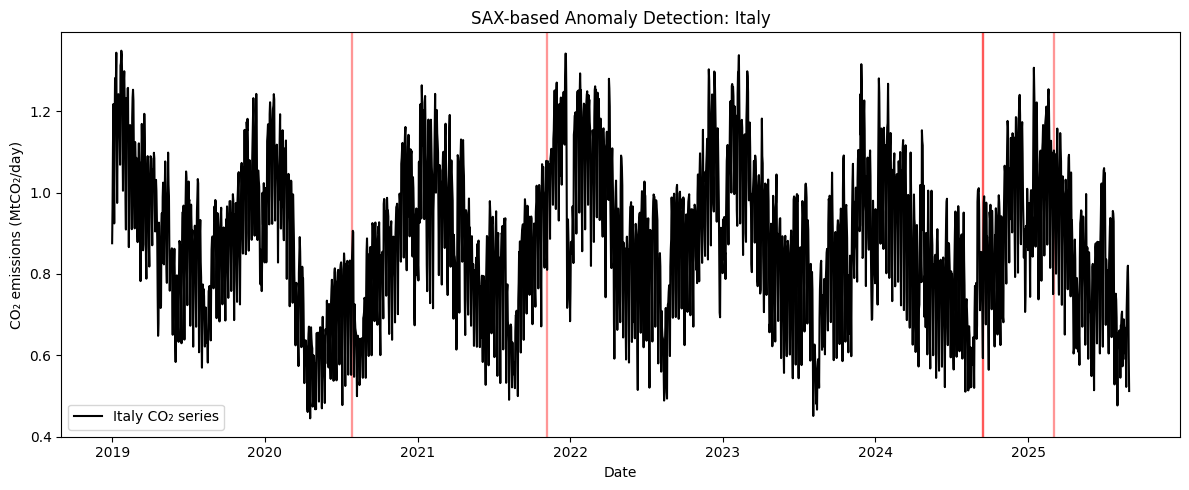

In [35]:
#ITALY
df_anoms_italy = detect_anomalies_for_country(
    "Italy", sax_by_country, df_country_grouped,
    probs, default_p, window_size=window_size, n=n, top_k=5
)
display(df_anoms_italy)
plot_country_with_anomalies("Italy", df_country_grouped, df_anoms_italy)

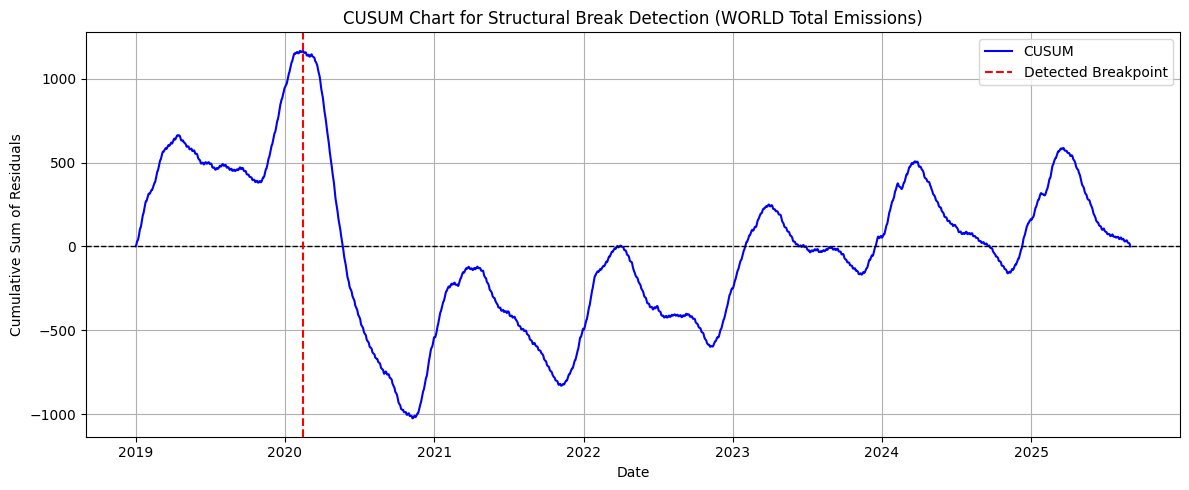

Possible Structural Break Date: 2020-02-14
CUSUM Statistic: 3.4495
p-value: 0.0000
Critical Values: [(1, 1.63), (5, 1.36), (10, 1.22)]


In [36]:
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.api import add_constant, OLS

# Prepare WORLD data
df_world = df[df['country'] == 'WORLD'].copy()
df_world = df_world.groupby('date')['value'].sum().reset_index()
df_world['date'] = pd.to_datetime(df_world['date'])
df_world = df_world.sort_values('date').reset_index(drop=True)
df_world['time_index'] = np.arange(len(df_world))

# Fit linear trend model
X_world = add_constant(df_world['time_index'])
y_world = df_world['value']
model_world = OLS(y_world, X_world).fit()

# Run CUSUM test
cusum_stat_world, p_value_world, crit_vals_world = breaks_cusumolsresid(model_world.resid)

# Compute cumulative residuals for visualization
residuals_world = model_world.resid
cusum_world = (residuals_world - residuals_world.mean()).cumsum()

# Identify possible structural break date
max_dev_index_world = cusum_world.abs().idxmax()
breakpoint_date_world = df_world.loc[max_dev_index_world, 'date']

# Plot CUSUM chart with breakpoint line
plt.figure(figsize=(12, 5))
plt.plot(df_world['date'], cusum_world, label='CUSUM', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(breakpoint_date_world, color='red', linestyle='--', linewidth=1.5, label='Detected Breakpoint')
plt.title('CUSUM Chart for Structural Break Detection (WORLD Total Emissions)')
plt.xlabel('Date')
plt.ylabel('Cumulative Sum of Residuals')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



# Display results
print(f"Possible Structural Break Date: {breakpoint_date_world.date()}")
print(f"CUSUM Statistic: {cusum_stat_world:.4f}")
print(f"p-value: {p_value_world:.4f}")
print(f"Critical Values: {crit_vals_world}")

# my **part**

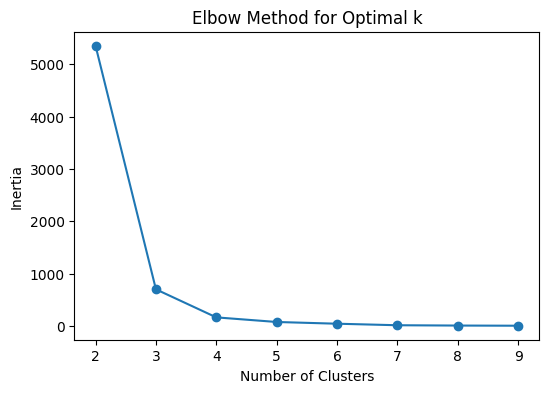

In [37]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Aggregate CO2 values by country and date
df_country_grouped = df.groupby(['country', 'date'], as_index=False)['value'].sum()

# Pivot the table to have countries as rows and dates as columns
pivot_df = df_country_grouped.pivot(index='country', columns='date', values='value')

# Fill missing values with 0 (or another appropriate strategy)
pivot_df = pivot_df.fillna(0)

# Scale the data
scaler = StandardScaler()
pivot_scaled = scaler.fit_transform(pivot_df)
pivot_scaled = pd.DataFrame(pivot_scaled, index=pivot_df.index, columns=pivot_df.columns)


# Try different cluster numbers
inertias = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init for newer sklearn versions
    kmeans.fit(pivot_scaled)
    inertias.append(kmeans.inertia_)

# Elbow Method
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(K, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# Choose best k (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init
pivot_scaled['cluster'] = kmeans.fit_predict(pivot_scaled)

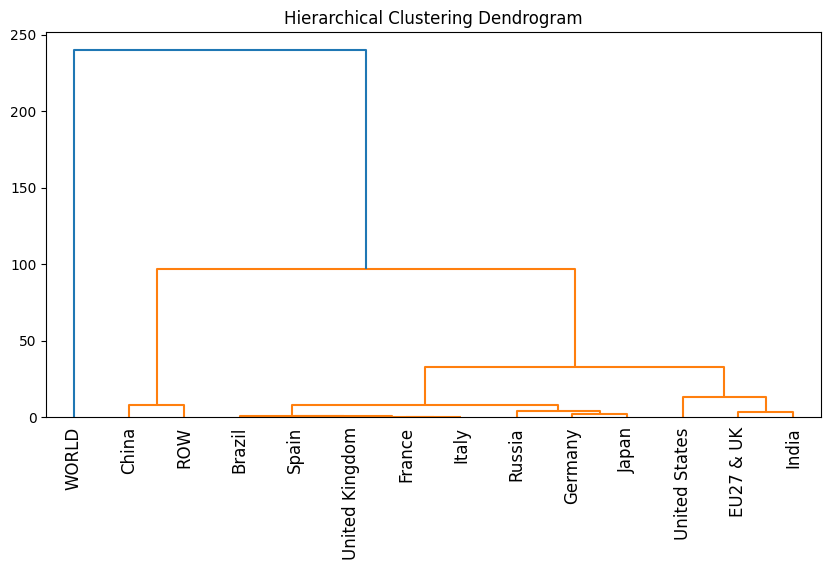

In [38]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(pivot_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=pivot_scaled.index, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

# Choose number of clusters
pivot_scaled['cluster'] = fcluster(Z, t=3, criterion='maxclust')


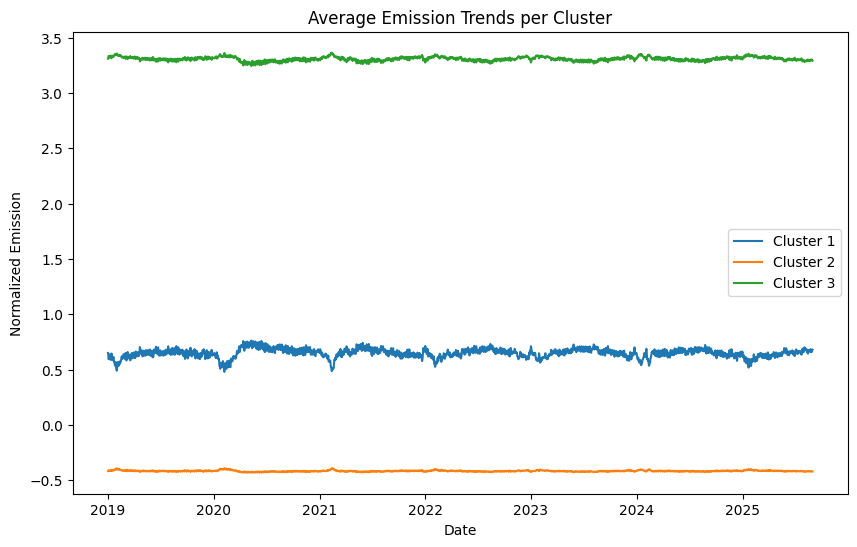

In [39]:
plt.figure(figsize=(10,6))
for cluster in sorted(pivot_scaled['cluster'].unique()):
    cluster_countries = pivot_scaled[pivot_scaled['cluster'] == cluster].drop('cluster', axis=1)
    plt.plot(cluster_countries.mean(), label=f'Cluster {cluster}')
plt.title('Average Emission Trends per Cluster')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Normalized Emission')
plt.show()


In [40]:
pivot_scaled.reset_index()[['country', 'cluster']].to_csv('country_clusters.csv', index=False)


### 📊 Summary
- K-Means and Hierarchical clustering identified 3 main groups of countries with similar CO₂ emission patterns.
- Dynamic Time Warping (DTW) captured shape-based similarities between time series.
- Cluster assignments saved to `country_clusters.csv` for further analysis and visualization.


if i want to predict it i should move it to supervised learinig because clustering is unsupervised learning

this 1 block  below is just for USA

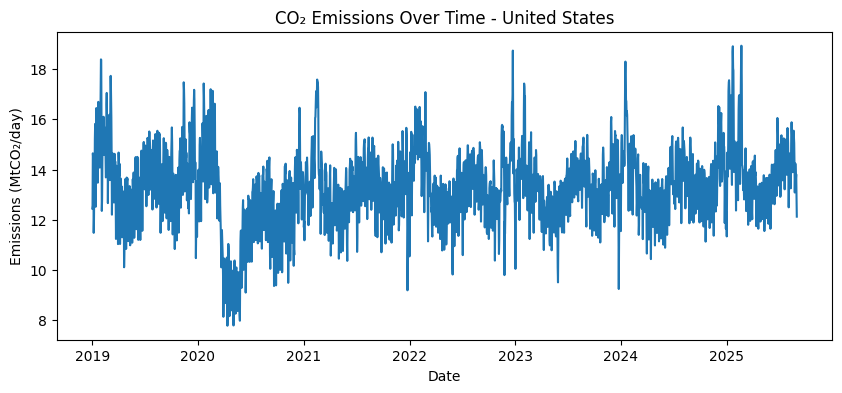

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0639 - val_loss: 0.0092
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0152 - val_loss: 0.0092
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0131 - val_loss: 0.0089
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0130 - val_loss: 0.0091
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0123 - val_loss: 0.0085
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0128 - val_loss: 0.0101
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0127 - val_loss: 0.0086
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0123 - val_loss: 0.0080
Epoch 9/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0123 - val_loss: 0.0079
Epoch 10/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0125 - val_loss: 0.0085
Epoch 11/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0107 - val_loss: 0.0100
Epoch 12/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

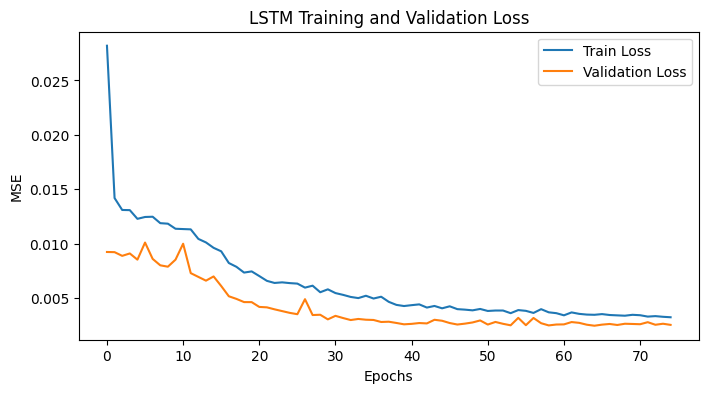

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Root Mean Squared Error (RMSE): 0.546


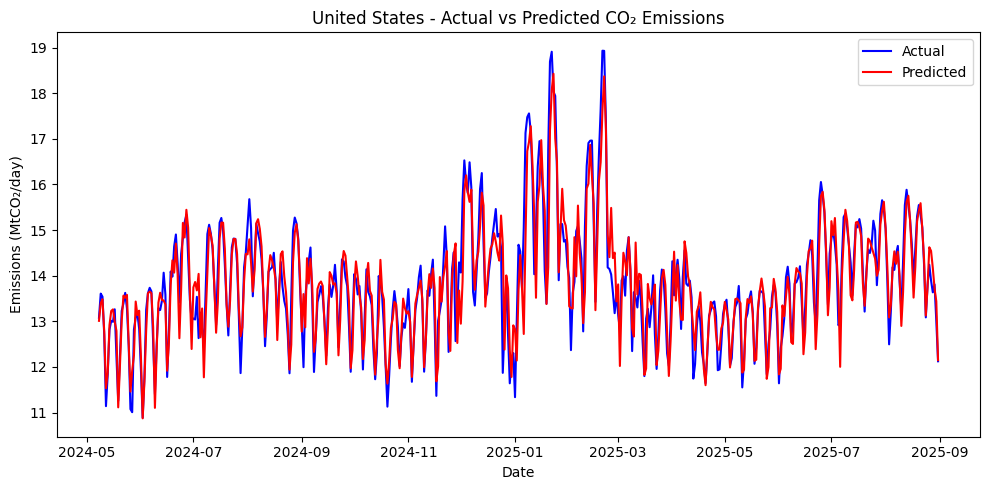

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


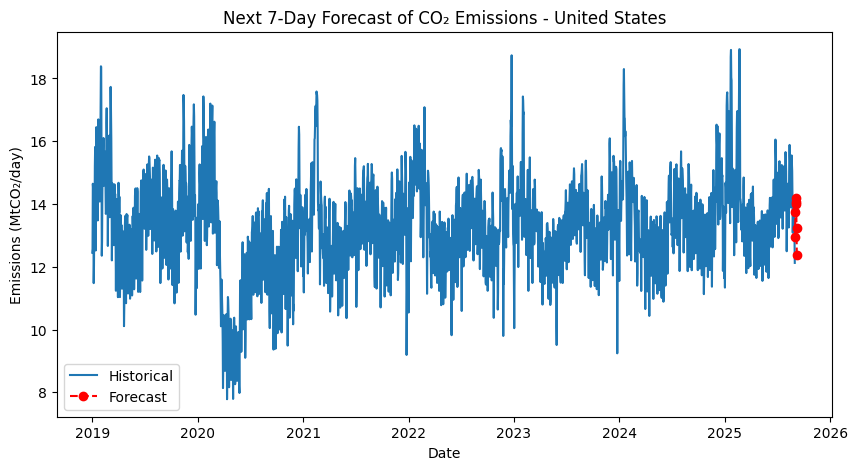

In [41]:
# ============================================================
# SECTION 6: TIME SERIES FORECASTING USING LSTM
# ============================================================
# We use one country's emission data to forecast future emissions
# (Example: United States)
# ============================================================

import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

# Select a country to forecast
country = "United States"
df_country = df[df['country'] == country].groupby('date', as_index=False)['value'].sum().sort_values('date')

# Plot the country's emissions
plt.figure(figsize=(10,4))
plt.plot(df_country['date'], df_country['value'])
plt.title(f"CO₂ Emissions Over Time - {country}")
plt.xlabel("Date")
plt.ylabel("Emissions (MtCO₂/day)")
plt.show()

# ============================================================
# Prepare data for LSTM
# ============================================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_country[['value']])

def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled, window_size)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# ============================================================
# Build LSTM model
# ============================================================
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ============================================================
# Train the model
# ============================================================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# ============================================================
# Evaluate and visualize
# ============================================================
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Predictions
pred = model.predict(X_test)
pred_inv = scaler.inverse_transform(pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

rmse = math.sqrt(mean_squared_error(y_test_inv, pred_inv))
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

plt.figure(figsize=(10,5))
plt.plot(df_country['date'][-len(y_test):], y_test_inv, label='Actual', color='blue')
plt.plot(df_country['date'][-len(y_test):], pred_inv, label='Predicted', color='red')
plt.title(f"{country} - Actual vs Predicted CO₂ Emissions")
plt.xlabel("Date")
plt.ylabel("Emissions (MtCO₂/day)")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Forecast the next 7 days
# ============================================================
future_days = 7
last_sequence = scaled[-window_size:]
future_preds = []
current_seq = last_sequence

for _ in range(future_days):
    pred_future = model.predict(current_seq.reshape(1, window_size, 1))[0][0]
    future_preds.append(pred_future)
    current_seq = np.append(current_seq[1:], pred_future).reshape(window_size, 1)

future_preds_inv = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))
future_dates = pd.date_range(df_country['date'].max() + pd.Timedelta(days=1), periods=future_days)

plt.figure(figsize=(10,5))
plt.plot(df_country['date'], df_country['value'], label='Historical')
plt.plot(future_dates, future_preds_inv, 'ro--', label='Forecast')
plt.title(f"Next {future_days}-Day Forecast of CO₂ Emissions - {country}")
plt.xlabel("Date")
plt.ylabel("Emissions (MtCO₂/day)")
plt.legend()
plt.show()


# this code is for all the **countries**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


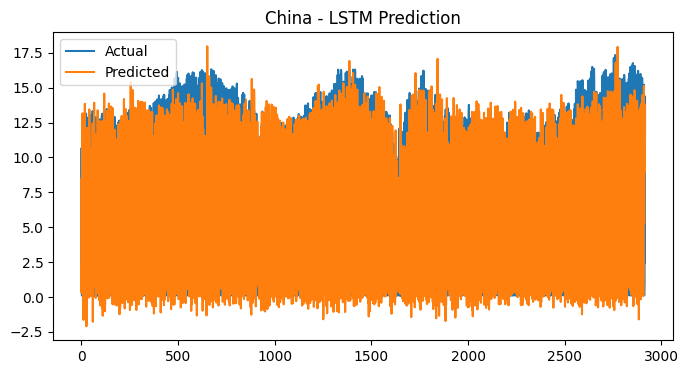

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


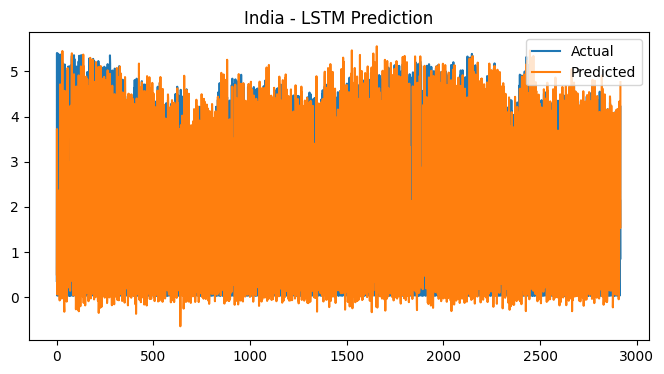

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


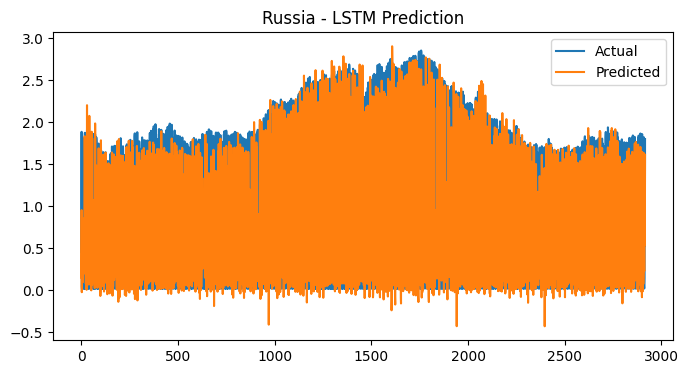

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


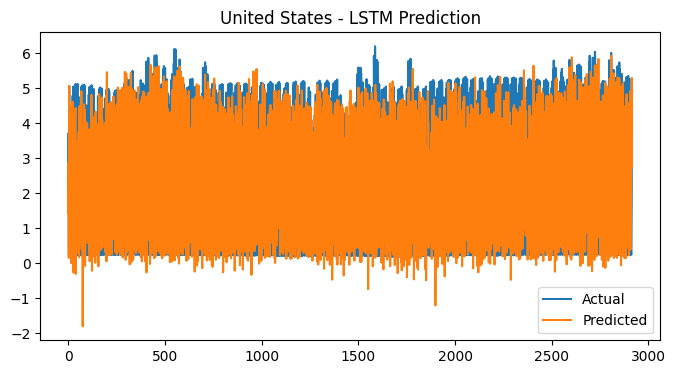

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
                    RMSE  last_real  last_pred
Spain           0.045709   0.047824   0.123979
Italy           0.056696   0.073844   0.127578
United Kingdom  0.059910   0.039177   0.124562
France          0.064053   0.010555   0.010678
Brazil          0.069036   0.087559   0.117276
Germany         0.104916   0.222584   0.229473
Japan           0.154126   1.017260   0.953446
Russia          0.253510   1.799180   1.611620
EU27 & UK       0.453957   0.815406   0.676007
India           0.536425   4.217190   4.763047
United States   0.671423   4.078000   3.789066
ROW             1.398505   9.110200  10.378158
China           1.837245  14.357800   9.417243
WORLD           4.599784   4.994940   4.568361


In [42]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Assuming df has columns: ['date', 'country', 'value']
df['date'] = pd.to_datetime(df['date'])
countries = df['country'].unique()

# Dictionary to store results
results = {}

# Function to create sequences
def create_sequences(data, time_steps=30):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Loop over countries
for country in countries:
    country_data = df[df['country'] == country].sort_values('date')
    values = country_data['value'].values.reshape(-1, 1)

    if len(values) < 60:
        # Skip countries with too few data points
        continue

    # Normalize
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(values)

    # Create sequences
    X, y = create_sequences(scaled_values, 30)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    # Split into train/test
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Define model
    model = Sequential([
        LSTM(64, return_sequences=False, input_shape=(X_train.shape[1], 1)),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train model
    model.fit(X_train, y_train, validation_data=(X_test, y_test),
              epochs=50, batch_size=16, verbose=0, callbacks=[early_stop])

    # Predict
    y_pred = model.predict(X_test)

    # Inverse transform
    y_pred_inv = scaler.inverse_transform(y_pred)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

    # Compute RMSE
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

    # Store results
    results[country] = {'RMSE': rmse, 'last_real': y_test_inv[-1][0], 'last_pred': y_pred_inv[-1][0]}

    # Optional: visualize a few key countries
    if country in ['China', 'United States', 'India', 'Russia']:
        plt.figure(figsize=(8, 4))
        plt.plot(y_test_inv, label='Actual')
        plt.plot(y_pred_inv, label='Predicted')
        plt.title(f'{country} - LSTM Prediction')
        plt.legend()
        plt.show()

# Display summary
results_df = pd.DataFrame(results).T
print(results_df.sort_values('RMSE'))


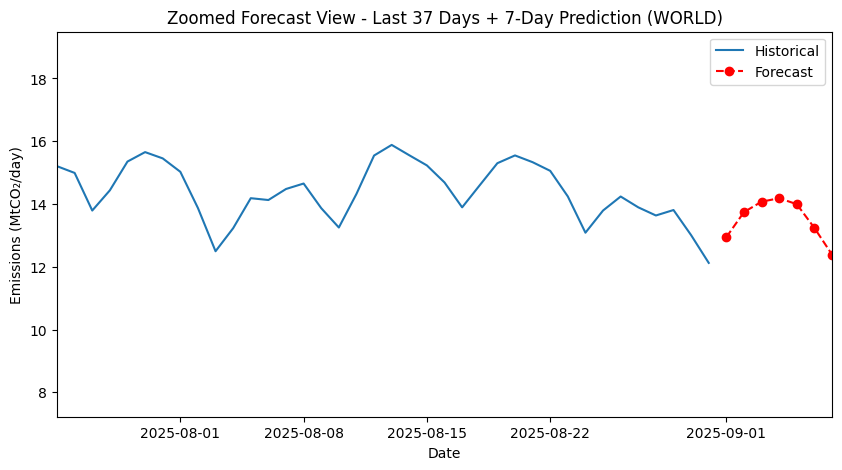

In [43]:
# Zoomed-in view: focus on the last historical days + forecast


# Define number of days to plot
zoom_days = 37

# Zoom start
zoom_start = df_country['date'].max() - pd.Timedelta(days=zoom_days)

plt.figure(figsize=(10,5))
plt.plot(df_country['date'], df_country['value'], label='Historical')
plt.plot(future_dates, future_preds_inv, 'ro--', label='Forecast')

# Zoom plot
plt.xlim(zoom_start, df_country['date'].max() + pd.Timedelta(days=future_days))
plt.title(f"Zoomed Forecast View - Last {zoom_days} Days + {future_days}-Day Prediction ({country})")
plt.xlabel("Date")
plt.ylabel("Emissions (MtCO₂/day)")
plt.legend()
plt.show()